# HQNN-Parallel no CIFAR-10: ideal, clássico e ruído IBM

O artigo usa CIFAR-10 com imagens RGB \(32\times32\), mantém 5 qubits por circuito, 4 circuitos quânticos e três repetições das camadas fortemente emaranhadas. Para CIFAR-10, o texto informa que a parte clássica usa três convoluções.

Aqui comparamos:

1. **HQNN ideal**
2. **Baseline clássico**
3. **HQNN + ruído medido no IBM QPU**

Os modelos são treinados por 8 épocas, com checkpoints, histórico, carregamento e calibração IBM nas épocas 0, 2, 4, 6 e 8.

## 1. Configuração

In [23]:
import json, copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import pennylane as qml

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda")
print(torch.cuda.get_device_name(0))

BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
N_TRAIN = 10000
N_TEST = 2000

N_QUBITS = 5
N_LAYERS = 3
N_CIRCUITS = 4
N_QFEATURES = 20

CALIB_EPOCHS = [0, 2, 4, 6, 8]
CALIB_INDICES = [0, 1, 2]
N_REPEATS = 2
IBM_SHOTS = 1000

OUTDIR = Path("hqnn_cifar10_runs")
OUTDIR.mkdir(exist_ok=True)

NVIDIA H100 PCIe


## 2. CIFAR-10

In [24]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

test_transform = transforms.ToTensor()

train_full = datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
test_full = datasets.CIFAR10("./data", train=False, download=True, transform=test_transform)

train_dataset = Subset(train_full, range(N_TRAIN))
test_dataset = Subset(test_full, range(N_TEST))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = train_full.classes

print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))
print(classes)

/home/schwarz/miniconda3/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Treino: 10000
Teste: 2000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Circuito quântico

In [25]:
qdev = qml.device("lightning.gpu", wires=N_QUBITS, shots=None)

@qml.qnode(qdev, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="X")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliY(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}

## 4. Modelos

A implementação usa três blocos convolucionais:

\[
3\times32\times32
\rightarrow 16\times16\times16
\rightarrow 32\times8\times8
\rightarrow 64\times4\times4
\rightarrow 1024.
\]

Depois:

\[
1024\rightarrow20\rightarrow4\times5\text{ qubits}\rightarrow20\rightarrow10.
\]

In [26]:
class CifarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return torch.flatten(self.conv(x), 1)


class ParallelQuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum_layers = nn.ModuleList([
            qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
            for _ in range(N_CIRCUITS)
        ])

    def forward(self, x):
        return torch.cat([
            layer(x[:, i*N_QUBITS:(i+1)*N_QUBITS])
            for i, layer in enumerate(self.quantum_layers)
        ], dim=1)


class HQNNCifar(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CifarCNN()
        self.fc1 = nn.Linear(64*4*4, N_QFEATURES)
        self.bn1 = nn.BatchNorm1d(N_QFEATURES)
        self.quantum = ParallelQuantumLayer()
        self.fc2 = nn.Linear(N_QFEATURES, 10)

    def features20(self, x):
        return F.relu(self.bn1(self.fc1(self.cnn(x))))

    def forward(self, x, qnoise=None):
        x = self.quantum(self.features20(x))
        if qnoise is not None:
            x = x + qnoise
        return self.fc2(x)


class ClassicalCifar(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CifarCNN()
        self.fc1 = nn.Linear(64*4*4, N_QFEATURES)
        self.bn1 = nn.BatchNorm1d(N_QFEATURES)
        self.hidden = nn.Linear(N_QFEATURES, N_QFEATURES)
        self.fc2 = nn.Linear(N_QFEATURES, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(self.cnn(x))))
        x = F.relu(self.hidden(x))
        return self.fc2(x)


def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [27]:
base_quantum = HQNNCifar().to(device)
initial_quantum_state = copy.deepcopy(base_quantum.state_dict())
base_classical = ClassicalCifar().to(device)

x, _ = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    f = base_quantum.features20(x)
    q = base_quantum.quantum(f)
    z = base_quantum.fc2(q)

print(x.shape, f.shape, q.shape, z.shape)
print("HQNN:", n_params(base_quantum))
print("Clássico:", n_params(base_classical))
print("Parâmetros quânticos:", sum(p.numel() for n, p in base_quantum.named_parameters() if "quantum" in n))

torch.Size([32, 3, 32, 32]) torch.Size([32, 20]) torch.Size([32, 20]) torch.Size([32, 10])
HQNN: 86466
Clássico: 86706
Parâmetros quânticos: 180


## 5. Checkpoints e histórico

In [28]:
def salvar_checkpoint(model, optimizer, history, epoch, tag):
    payload = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "history": history
    }
    torch.save(payload, OUTDIR / f"{tag}_epoch_{epoch:03d}.pt")
    torch.save(payload, OUTDIR / f"{tag}_latest.pt")
    with open(OUTDIR / f"{tag}_history.json", "w") as f:
        json.dump(history, f, indent=2)


def carregar_checkpoint(tag, epoch=None, model=None):
    path = OUTDIR / (f"{tag}_latest.pt" if epoch is None else f"{tag}_epoch_{epoch:03d}.pt")
    if model is None:
        model = HQNNCifar().to(device)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    if ckpt["optimizer_state"] is not None:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return model, optimizer, ckpt["history"], ckpt["epoch"]

## 6. Treinamento

In [29]:
@torch.no_grad()
def avaliar(model, loader):
    model.eval()
    loss_sum = correct = total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss_sum += F.cross_entropy(logits, labels, reduction="sum").item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.numel()

    return loss_sum / total, correct / total


def escolher_ruido(epoch, noise_by_epoch):
    epochs = np.array(sorted(noise_by_epoch))
    nearest = int(epochs[np.argmin(np.abs(epochs - epoch))])
    return noise_by_epoch[nearest], nearest


def treinar(model, tag, noise_by_epoch=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    salvar_checkpoint(model, optimizer, history, 0, tag)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum = correct = total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()

            if noise_by_epoch is None:
                logits = model(images)
                calib_epoch = None
            else:
                pool, calib_epoch = escolher_ruido(epoch, noise_by_epoch)
                idx = np.random.randint(0, len(pool), size=len(images))
                qnoise = torch.as_tensor(pool[idx], dtype=torch.float32, device=device)
                logits = model(images, qnoise=qnoise)

            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * labels.numel()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.numel()

        train_loss = loss_sum / total
        train_acc = correct / total
        test_loss, test_acc = avaliar(model, test_loader)

        for key, value in [
            ("train_loss", train_loss),
            ("train_acc", train_acc),
            ("test_loss", test_loss),
            ("test_acc", test_acc)
        ]:
            history[key].append(value)

        salvar_checkpoint(model, optimizer, history, epoch, tag)

        extra = "" if calib_epoch is None else f" | calibração IBM={calib_epoch}"

        print(
            f"Época {epoch:02d}/{EPOCHS} | "
            f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
            f"test loss={test_loss:.4f} acc={test_acc:.4f}{extra}"
        )

    return model, history

## 7. HQNN ideal — 8 épocas

In [30]:
model_ideal = HQNNCifar().to(device)
model_ideal.load_state_dict(copy.deepcopy(initial_quantum_state))
model_ideal, history_ideal = treinar(model_ideal, "ideal")

Época 01/20 | train loss=2.1143 acc=0.2418 | test loss=1.9185 acc=0.3365
Época 02/20 | train loss=1.7740 acc=0.3789 | test loss=1.6354 acc=0.4280
Época 03/20 | train loss=1.5929 acc=0.4447 | test loss=1.5124 acc=0.4810
Época 04/20 | train loss=1.4499 acc=0.4865 | test loss=1.6023 acc=0.4540
Época 05/20 | train loss=1.3597 acc=0.5229 | test loss=1.6012 acc=0.4330
Época 06/20 | train loss=1.2891 acc=0.5403 | test loss=1.3949 acc=0.5025
Época 07/20 | train loss=1.2165 acc=0.5701 | test loss=1.2827 acc=0.5490
Época 08/20 | train loss=1.1801 acc=0.5801 | test loss=1.2892 acc=0.5285
Época 09/20 | train loss=1.1404 acc=0.5926 | test loss=1.0877 acc=0.6275
Época 10/20 | train loss=1.0970 acc=0.6178 | test loss=1.3135 acc=0.5365
Época 11/20 | train loss=1.0756 acc=0.6193 | test loss=1.2348 acc=0.5655
Época 12/20 | train loss=1.0535 acc=0.6328 | test loss=1.2031 acc=0.5815
Época 13/20 | train loss=1.0190 acc=0.6425 | test loss=1.0401 acc=0.6295
Época 14/20 | train loss=0.9768 acc=0.6588 | test l

## 8. Baseline clássico — 8 épocas

In [20]:
model_classical = ClassicalCifar().to(device)
model_classical, history_classical = treinar(model_classical, "classical")

Época 01/20 | train loss=2.2280 acc=0.1570 | test loss=2.2942 acc=0.1080
Época 02/20 | train loss=2.1061 acc=0.2300 | test loss=2.0698 acc=0.2440
Época 03/20 | train loss=2.0168 acc=0.2660 | test loss=1.9511 acc=0.2720
Época 04/20 | train loss=1.9259 acc=0.2910 | test loss=1.9826 acc=0.2640
Época 05/20 | train loss=1.8412 acc=0.3130 | test loss=1.8258 acc=0.3220
Época 06/20 | train loss=1.7824 acc=0.3280 | test loss=1.8690 acc=0.3060
Época 07/20 | train loss=1.7284 acc=0.3630 | test loss=1.7275 acc=0.3400
Época 08/20 | train loss=1.6788 acc=0.3730 | test loss=2.8182 acc=0.1860
Época 09/20 | train loss=1.6210 acc=0.4160 | test loss=2.4474 acc=0.2200
Época 10/20 | train loss=1.6119 acc=0.4140 | test loss=1.7720 acc=0.3420
Época 11/20 | train loss=1.5091 acc=0.4810 | test loss=1.8012 acc=0.3480
Época 12/20 | train loss=1.4896 acc=0.4700 | test loss=1.9445 acc=0.2840
Época 13/20 | train loss=1.4875 acc=0.4530 | test loss=2.0997 acc=0.3140
Época 14/20 | train loss=1.4480 acc=0.4840 | test l

## 9. Convergência ideal × clássico

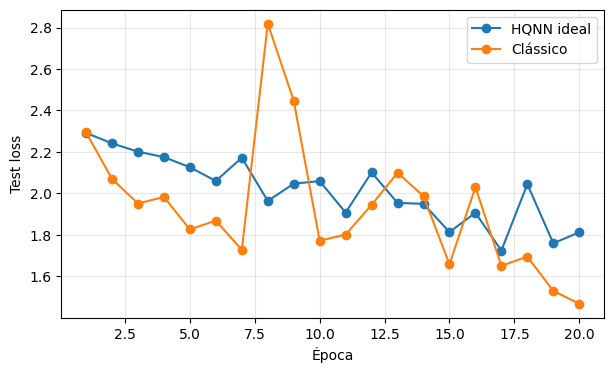

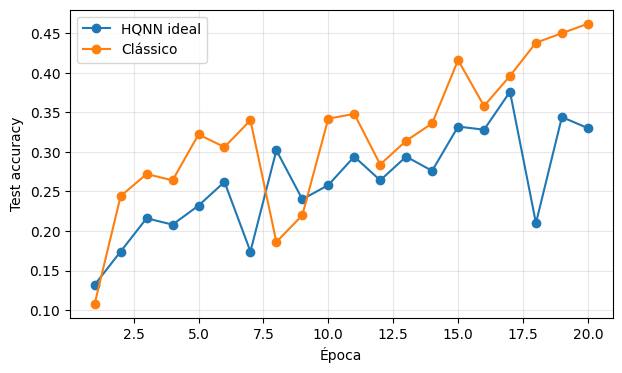

In [21]:
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs_axis, history_ideal["test_loss"], marker="o", label="HQNN ideal")
plt.plot(epochs_axis, history_classical["test_loss"], marker="o", label="Clássico")
plt.xlabel("Época")
plt.ylabel("Test loss")
plt.legend()
plt.grid(alpha=.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs_axis, history_ideal["test_acc"], marker="o", label="HQNN ideal")
plt.plot(epochs_axis, history_classical["test_acc"], marker="o", label="Clássico")
plt.xlabel("Época")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(alpha=.3)
plt.show()

## 10. IBM Quantum

In [22]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=N_QUBITS)

print("Backend:", backend.name)

Backend: ibm_kingston


In [ ]:
def make_qiskit_circuit(features5, weights):
    qc = QuantumCircuit(N_QUBITS)

    for q in range(N_QUBITS):
        qc.rx(float(features5[q]), q)

    for layer in range(weights.shape[0]):
        for q in range(N_QUBITS):
            phi, theta, omega = weights[layer, q]
            qc.rz(float(phi), q)
            qc.ry(float(theta), q)
            qc.rz(float(omega), q)

        r = layer + 1
        for q in range(N_QUBITS):
            qc.cx(q, (q + r) % N_QUBITS)

    return qc


Y_observables = [
    SparsePauliOp("IIIIY"),
    SparsePauliOp("IIIYI"),
    SparsePauliOp("IIYII"),
    SparsePauliOp("IYIII"),
    SparsePauliOp("YIIII")
]

pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
estimator = Estimator(mode=backend)

## 11. Validação PennyLane × Qiskit

In [ ]:
model_check, _, _, _ = carregar_checkpoint("ideal", epoch=0)
image = test_dataset[0][0].unsqueeze(0).to(device)

with torch.no_grad():
    features = model_check.features20(image)
    pl = model_check.quantum.quantum_layers[0](features[:, :5]).detach().cpu().numpy()[0]

f5 = features[0, :5].detach().cpu().numpy()
w5 = model_check.quantum.quantum_layers[0].weights.detach().cpu().numpy()

qc = make_qiskit_circuit(f5, w5)
state = Statevector.from_instruction(qc)
qk = np.array([np.real(state.expectation_value(obs)) for obs in Y_observables])

print("Máxima diferença:", np.max(np.abs(pl - qk)))

In [ ]:
def quantum_weights_np(model):
    return [layer.weights.detach().cpu().numpy() for layer in model.quantum.quantum_layers]


def run_quantum_layer_ibm(features20, weights4, shots=IBM_SHOTS):
    pubs = []

    for i in range(N_CIRCUITS):
        f5 = features20[i*N_QUBITS:(i+1)*N_QUBITS]
        qc = make_qiskit_circuit(f5, weights4[i])
        isa_qc = pm.run(qc)
        isa_obs = [obs.apply_layout(isa_qc.layout) for obs in Y_observables]
        pubs.append((isa_qc, isa_obs))

    estimator.options.default_shots = shots
    job = estimator.run(pubs)

    print("Job:", job.job_id())

    result = job.result()

    means = np.concatenate([np.asarray(r.data.evs, dtype=float) for r in result])
    stds = np.concatenate([np.asarray(r.data.stds, dtype=float) for r in result])

    return means, stds

## 12. Calibração IBM por checkpoint

Para cada época de calibração calculamos:

\[
\Delta q=q_{\rm IBM}-q_{\rm ideal}.
\]

Também salvamos MAE, bias e correlação.

In [ ]:
noise_by_epoch = {}
noise_metrics = []

for epoch in CALIB_EPOCHS:
    print(f"\nCalibração da época {epoch}")

    model_epoch, _, _, _ = carregar_checkpoint("ideal", epoch=epoch)
    model_epoch.eval()
    weights4 = quantum_weights_np(model_epoch)

    residuals_epoch = []
    shot_stds_epoch = []
    ideal_epoch = []
    ibm_epoch = []

    for idx in CALIB_INDICES:
        image = test_dataset[idx][0].unsqueeze(0).to(device)

        with torch.no_grad():
            features = model_epoch.features20(image)
            ideal = model_epoch.quantum(features).detach().cpu().numpy()[0]

        features_np = features[0].detach().cpu().numpy()

        for _ in range(N_REPEATS):
            measured, std = run_quantum_layer_ibm(features_np, weights4)
            residuals_epoch.append(measured - ideal)
            shot_stds_epoch.append(std)
            ideal_epoch.append(ideal)
            ibm_epoch.append(measured)

    residuals_epoch = np.asarray(residuals_epoch)
    shot_stds_epoch = np.asarray(shot_stds_epoch)
    ideal_epoch = np.asarray(ideal_epoch)
    ibm_epoch = np.asarray(ibm_epoch)

    noise_by_epoch[epoch] = residuals_epoch

    fi = ideal_epoch.ravel()
    fq = ibm_epoch.ravel()

    mae = np.mean(np.abs(fq - fi))
    bias = np.mean(fq - fi)
    corr = np.corrcoef(fi, fq)[0,1]

    noise_metrics.append({
        "epoch": epoch,
        "mae": float(mae),
        "bias": float(bias),
        "correlation": float(corr)
    })

    np.savez(
        OUTDIR / f"ibm_noise_epoch_{epoch:03d}.npz",
        residuals=residuals_epoch,
        shot_stds=shot_stds_epoch,
        ideal=ideal_epoch,
        ibm=ibm_epoch,
        shots=IBM_SHOTS
    )

    print(f"MAE={mae:.4f} | bias={bias:+.4f} | r={corr:.4f}")

with open(OUTDIR / "ibm_noise_metrics.json", "w") as f:
    json.dump(noise_metrics, f, indent=2)

## 13. Carregar calibrações salvas

In [ ]:
noise_by_epoch = {}

for epoch in CALIB_EPOCHS:
    d = np.load(OUTDIR / f"ibm_noise_epoch_{epoch:03d}.npz")
    noise_by_epoch[epoch] = d["residuals"]

with open(OUTDIR / "ibm_noise_metrics.json") as f:
    noise_metrics = json.load(f)

print({k:v.shape for k,v in noise_by_epoch.items()})

## 14. Evolução do ruído

In [ ]:
ep = np.array([m["epoch"] for m in noise_metrics])
mae = np.array([m["mae"] for m in noise_metrics])
bias = np.array([m["bias"] for m in noise_metrics])
corr = np.array([m["correlation"] for m in noise_metrics])

plt.figure(figsize=(7,4))
plt.plot(ep, mae, marker="o", label="MAE")
plt.plot(ep, np.abs(bias), marker="o", label="|bias|")
plt.xlabel("Época")
plt.ylabel("Erro em <Y>")
plt.legend()
plt.grid(alpha=.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(ep, corr, marker="o")
plt.xlabel("Época")
plt.ylabel("Correlação ideal × IBM")
plt.ylim(0, 1.02)
plt.grid(alpha=.3)
plt.show()

## 15. Ideal × IBM no checkpoint final

In [ ]:
d = np.load(OUTDIR / f"ibm_noise_epoch_{CALIB_EPOCHS[-1]:03d}.npz")

xi = d["ideal"].ravel()
xq = d["ibm"].ravel()
xs = d["shot_stds"].ravel()

plt.figure(figsize=(6,6))
plt.errorbar(xi, xq, yerr=xs, fmt="o", capsize=2, alpha=.7)
plt.plot([-1,1], [-1,1], "--")
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xlabel("Simulador ideal")
plt.ylabel("IBM QPU")
plt.title(f"Época {CALIB_EPOCHS[-1]}")
plt.grid(alpha=.3)
plt.show()

## 16. HQNN + ruído IBM — 8 épocas

In [ ]:
model_noisy = HQNNCifar().to(device)
model_noisy.load_state_dict(copy.deepcopy(initial_quantum_state))

model_noisy, history_noisy = treinar(
    model_noisy,
    "ibm_noise",
    noise_by_epoch=noise_by_epoch
)

## 17. Comparação final

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(epochs_axis, history_classical["test_loss"], marker="o", label="Clássico")
plt.plot(epochs_axis, history_ideal["test_loss"], marker="o", label="HQNN ideal")
plt.plot(epochs_axis, history_noisy["test_loss"], marker="o", label="HQNN + ruído IBM")
plt.xlabel("Época")
plt.ylabel("Test loss")
plt.legend()
plt.grid(alpha=.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs_axis, history_classical["test_acc"], marker="o", label="Clássico")
plt.plot(epochs_axis, history_ideal["test_acc"], marker="o", label="HQNN ideal")
plt.plot(epochs_axis, history_noisy["test_acc"], marker="o", label="HQNN + ruído IBM")
plt.xlabel("Época")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(alpha=.3)
plt.show()

print("Parâmetros treináveis")
print("Clássico:", n_params(model_classical))
print("HQNN ideal:", n_params(model_ideal))
print("HQNN + ruído IBM:", n_params(model_noisy))

## 18. Propagação da incerteza estatística

In [ ]:
epoch = CALIB_EPOCHS[-1]
d = np.load(OUTDIR / f"ibm_noise_epoch_{epoch:03d}.npz")

q_mean = d["ibm"][0]
q_std = d["shot_stds"][0]

model_epoch, _, _, _ = carregar_checkpoint("ideal", epoch=epoch)

label = int(test_dataset[CALIB_INDICES[0]][1])
N_MC = 10000

mu = torch.as_tensor(q_mean, dtype=torch.float32, device=device)
sigma = torch.as_tensor(q_std, dtype=torch.float32, device=device)

samples = mu[None,:] + torch.randn(N_MC, N_QFEATURES, device=device) * sigma[None,:]

with torch.no_grad():
    logits = model_epoch.fc2(samples)
    probs = torch.softmax(logits, 1)

targets = torch.full((N_MC,), label, dtype=torch.long, device=device)
losses = F.cross_entropy(logits, targets, reduction="none")

pmean = probs.mean(0).cpu().numpy()
pstd = probs.std(0).cpu().numpy()

for c in range(10):
    print(f"{classes[c]:10s}: {pmean[c]:.4f} ± {pstd[c]:.4f}")

print(f"Loss: {losses.mean().item():.4f} ± {losses.std().item():.4f}")

## 19. Carregar modelos

In [ ]:
model_ideal_loaded, _, history_ideal_loaded, epoch_ideal = carregar_checkpoint("ideal")
model_noisy_loaded, _, history_noisy_loaded, epoch_noisy = carregar_checkpoint("ibm_noise")

classical_loaded = ClassicalCifar().to(device)
classical_loaded, _, history_classical_loaded, epoch_classical = carregar_checkpoint(
    "classical",
    model=classical_loaded
)

print("Ideal:", epoch_ideal)
print("Ruído IBM:", epoch_noisy)
print("Clássico:", epoch_classical)

## Interpretação

No CIFAR-10, a dificuldade maior está na extração clássica de características de imagens RGB naturais. O gargalo quântico continua recebendo apenas 20 números.

A calibração IBM é repetida ao longo do treinamento para testar se o erro de hardware depende do checkpoint. O treinamento ruidoso usa bootstrap dos resíduos reais medidos no QPU, permitindo estudar oito épocas sem executar todos os batches no hardware físico.